# Data Cleaning and Visualization On The Titanic Dataset

In [1]:
# Importing pandas
import pandas as pd

# Importing matplotlib for charts
import matplotlib as plt

## Reading the File

In [5]:
# Making dataframe from xlsx

df = pd.read_excel('titanic.xlsx')

#print dataframe
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Printing the first 5 columns of the dataset

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Looking for problems in the dataset


In [11]:
#Here we are checking the whole info about the dataset including the amount of non
#null values in each column and the data type of each column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
# Here we are checking the number of null values in the dataset

df.isnull().sum()



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

As we can see, there are 177 null values in the age column and 687 null values in the 
cabin column, 2 null values in the embarked column.

Now for cabin we can see that there are alot of missing values there and we cannot
guess peoples cabin names so filling it wont make sense; therefore we drop it

In [13]:
# Dropping cabin
df = df.drop(columns=['Cabin'])

In [14]:
# Now lets check if cabin column is still there

df.head()

# Its not

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

Next for age we see that age also has a lot of missing values but we can't just
fill it with 0's like we did in the NYC dataset because it is important for analysis
so we fill it with the median because median is more stable and its better than the
mean which would be affected by old ages like 80 and the likes


Note: We didnt fill age with 0 because age is important for data analysis and no one is zero years old it doesnt make sense. 
We use median instead of mean because mean would be affected by outliers like 80 years old with are very old and will mess up the whole data with inaccurate/misleading data whereas using median will be more stable

In [18]:
# Filling the null cells for age with the median of the ages
df['Age'] = df['Age'].fillna(df['Age'].median())

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

Now for the embarked column which has only 2 missing values, we will just fill them
with the mode (the most common values) of the values

Note: Its okay to fill embarked not cabin because embarked only has 2 missing values while cabin has a lot and embarked is dealing with like letter codes which can easily be replaced by like the most recurring letter code whereas for cabin we cannot guess the names of cabin's

In [20]:
# Filling it with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#Checking for null values once more
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

As you can see we've succeded in cleaning the dataset's null values

In [23]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

There are no columns with duplicates

### Lets change how the capitalization for values in "sex" column are
### From all small letters to the first letter of each capitalized.

In [26]:
df['Sex'] = df['Sex'].str.title()

In [27]:
# Checking result
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,S


Done!!!

## Visualization

## Visual 1: Survival Count

#### Did more people survive or die?

<Axes: xlabel='Survived'>

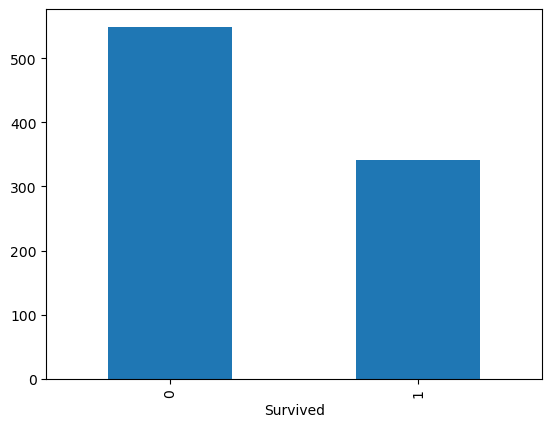

In [28]:
# Checking to see the number of people that survived using a bar chart

df['Survived'].value_counts().plot(kind='bar')

### Insight

The zero represents deaths and the 1 represents survivals
From the bar chart we can see that a huge number of people did not survive meaning
the accident resulted in a high death rate

### VISUAL 2: Survival by Gender

#### Could Gender have influenced the survival chances?

<Axes: xlabel='Sex'>

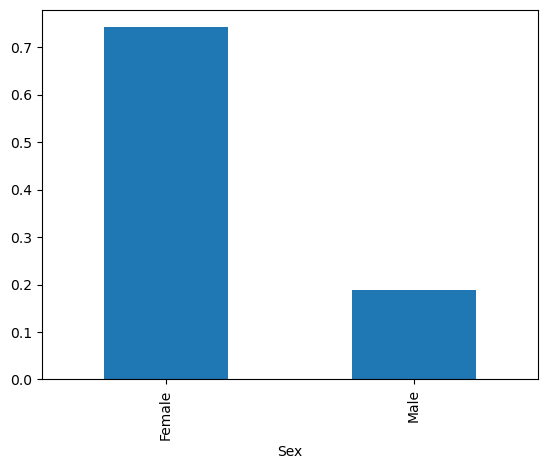

In [33]:
# Checking to see if gender affected the survival chances
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

### Insight

Wow, The bar chart shows that females had a higher rate of survivors, indicating
that they were more prioritized than males in the evacuation process

### VISUAL 3: Survival by Class

#### Did the social class of the people matter?

<Axes: xlabel='Pclass'>

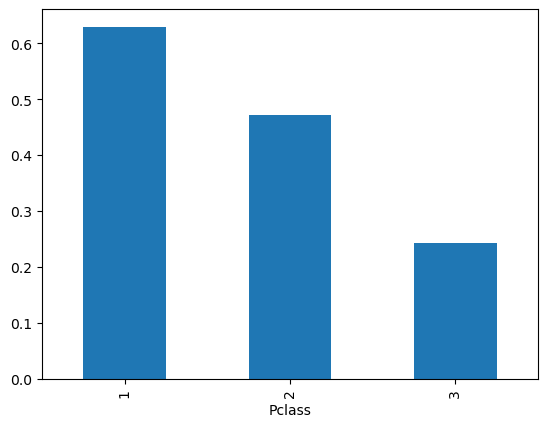

In [34]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

### Insight

This shows that passengers in higher social classes in the Titanic had higher survival
rates which means that social and economic status influenced access to safety
in the evacuation process